# 01 — Baseline regression (single feature)

## Goal
Pick the single feature most likely related to rent in order to predict `rentGross` using linear regression: gradient descent will be implemented by hand in NumPy for educational purposes.

No multi-feature modeling, no regularization, no polynomial features in this notebook.

## Dataset
Starts from the two datasets produced in `00_data_cleaning.ipynb`.

## Target
`rentGross`, same choice and reasoning as in `00_data_cleaning.ipynb`.

----------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
train_df = pd.read_csv('../data/train.csv')
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   type           586 non-null    str    
 1   postcode       586 non-null    int64  
 2   lat            586 non-null    float64
 3   lon            586 non-null    float64
 4   livingSpace    586 non-null    float64
 5   numberOfRooms  586 non-null    float64
 6   floor          586 non-null    float64
 7   hasGarage      586 non-null    str    
 8   hasParking     586 non-null    str    
 9   hasBalcony     586 non-null    str    
 10  hasElevator    586 non-null    str    
 11  rentGross      586 non-null    float64
dtypes: float64(6), int64(1), str(5)
memory usage: 55.1 KB


In [3]:
train_df.head()

,type,postcode,lat,lon,livingSpace,numberOfRooms,floor,hasGarage,hasParking,hasBalcony,hasElevator,rentGross
0,"['APARTMENT', 'FLAT']",8600,47.397272,8.601042,147.0,4.5,26.0,unknown,unknown,True,True,4950.0
1,"['APARTMENT', 'LOFT']",4900,47.213072,7.789612,167.0,2.5,2.0,True,unknown,unknown,unknown,2225.0
2,"['APARTMENT', 'FLAT']",8610,47.344682,8.734462,57.0,2.5,3.0,True,unknown,True,unknown,1782.0
3,"['APARTMENT', 'FLAT']",8266,47.661842,8.978512,103.0,3.5,2.0,unknown,True,True,unknown,1600.0
4,"['APARTMENT', 'FLAT']",9548,47.521512,8.930522,97.0,4.5,1.0,unknown,True,unknown,True,1985.0


## 1. Pick the best feature

To build the most accurate model possible, we pick the feature most correlated with `rentGross`. A bar chart lets us visualize every feature's correlation with the target at a glance.

Non-numerical features are excluded, since correlation requires numeric values.

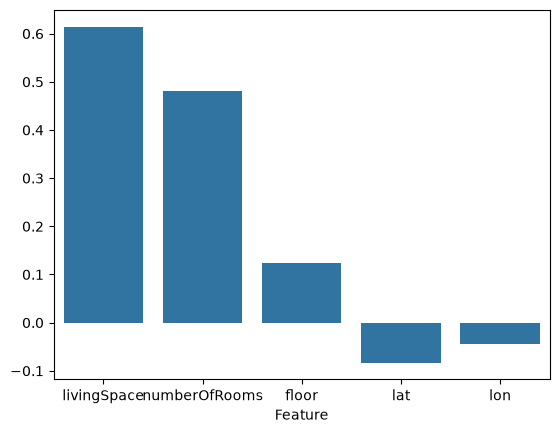

In [4]:
# Calculate correlation
corr_with_target = train_df[['livingSpace', 'numberOfRooms', 'floor', 'lat', 'lon']].corrwith(train_df['rentGross'])

# Sort values for a clearer plot
corr_with_target = corr_with_target.sort_values(ascending=False, key=abs)
corr_with_target.index.name = 'Feature'

sns.barplot(x=corr_with_target.index, y=corr_with_target.values)
plt.show()

Even though the correlation values are clear, we'll still check the scatter plots for both `livingSpace` and `numberOfRooms` before choosing the feature,
in case the numbers are inflated by outliers or unusual listings.

## 2. Scatter plots

Verify that the correlation is really linear for both the `livingSpace` and `numberOfRooms` columns.

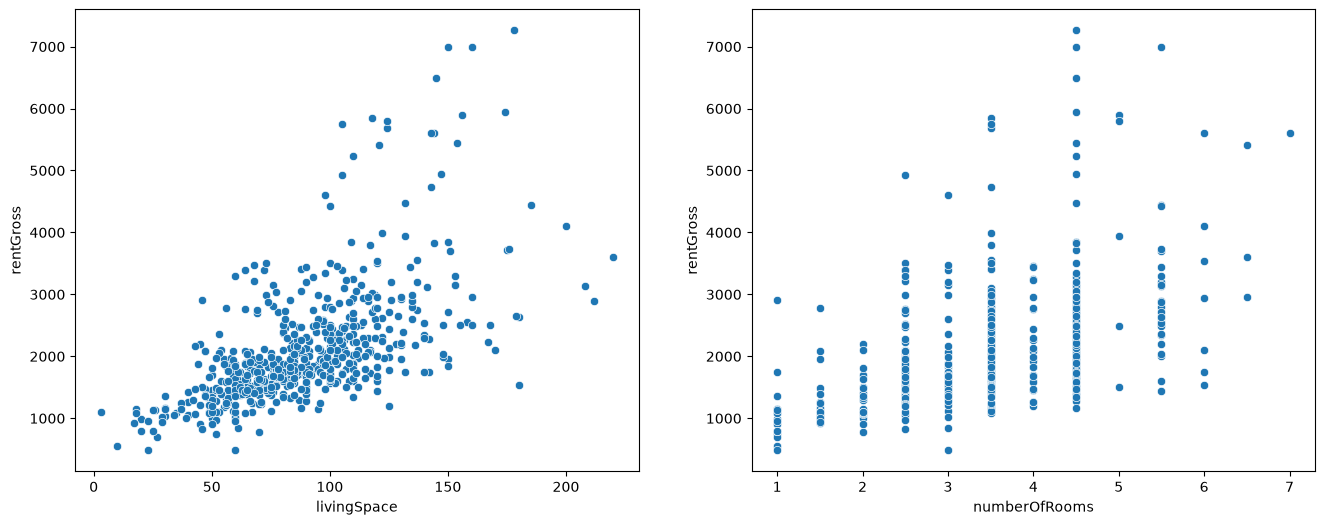

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=train_df, x='numberOfRooms', y='rentGross', ax=axes[1])
sns.scatterplot(data=train_df, x='livingSpace', y='rentGross', ax=axes[0])

plt.show()

## 3. Feature choice

Both features show a positive relationship with `rentGross`, but `livingSpace` shows a clearer, more consistent trend. 
`numberOfRooms` is discrete, and overlaps heavily at each value.

We will use `livingSpace` as the single feature for this baseline model.

In [6]:
# Produce np.array with only the 'livingSpace' and 'rentGross' values
x_train = train_df['livingSpace'].values
y_train = train_df['rentGross'].values

## 4. Prediction function

`predict` implements the linear regression model $f_{w,b}(x) = wx + b$ directly, kept separate from the cost function so it can be reused later for gradient descent and for 
predictions on the test set.

In [7]:
def predict(x, w, b):
    return w * x + b

## 5. Cost function

We implement the cost function $J(w, b) = \frac{1}{2m} \sum^m_{i=1}(\hat{y}^{(i)}-y^{(i)})^2$ by hand instead of relying on a library, since the goal is also to understand the math behind gradient descent, not just get a working model.

In [8]:
def compute_cost(x, y, w, b):
    m = len(x)
    cost = 0
    
    for i in range(m):
        prediction = predict(x[i], w, b)
        cost = cost + (prediction - y[i])**2

    total_cost = 1 / (2 * m) * cost
    return total_cost

## 6. Gradient descent

Same reasoning as the cost function, implemented by hand to understand the mechanics.

In [9]:
def compute_gradient(x, y, w, b):
    m = len(x)

    # The two derivatives
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        prediction = predict(x[i], w, b)

        error = prediction - y[i]

        dj_dw_i = error * x[i]

        dj_db_i = error

        dj_dw = dj_dw + dj_dw_i
        dj_db = dj_db + dj_db_i
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [10]:
def gradient_descent(x, y, w, b, alpha, num_iters):
    history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w_tmp = w - alpha * dj_dw
        b_tmp = b - alpha * dj_db
        w = w_tmp
        b = b_tmp
        history.append(compute_cost(x, y, w, b))

    return w, b, history


## 7. Comparing gradient descent and scikit-learn

We run gradient descent twice with the same `alpha`, but a different number of iterations (1,000 vs 50,000), then compare both against `LinearRegression` from scikit-learn, trained on the same data.

`alpha` was chosen by trial and error, not derived analytically. Starting from a very small value (`0.0001`) that converged but very slowly, we tried a larger one (`0.0005`) which diverged. Landing between the two (`0.0002`) gave stable convergence without overflow.

Each subsection looks at the comparison from a different angle: final parameters, fitted line and performance on the test set.

In [11]:
# Initial guesses
w_init = 0
b_init = 0

In [12]:
# Setup gradient descent method
w_1k, b_1k, history_1k = gradient_descent(x_train, y_train, w_init, b_init, 0.0002, 1000)
w_50k, b_50k, history_50k = gradient_descent(x_train, y_train, w_init, b_init, 0.0002, 50000)

In [13]:
# Setup sklearn method
x_train_2d = x_train.reshape(-1, 1)

sklearn_model = LinearRegression()
sklearn_model.fit(x_train_2d, y_train);
w_sklearn = sklearn_model.coef_[0]
b_sklearn = sklearn_model.intercept_

sklearn_cost = compute_cost(x_train, y_train, w_sklearn, b_sklearn)

### 7.1 Final values

The table below shows `w`, `b`, and the final cost for all three approaches, side by side.

In [14]:
comparison = pd.DataFrame({
    'Model': ['1k iterations', '50k iterations', 'sklearn'],
    'final_cost': [history_1k[-1], history_50k[-1], sklearn_cost],
    'w': [w_1k, w_50k, w_sklearn],
    'b': [b_1k, b_50k, b_sklearn]
})
comparison

,Model,final_cost,w,b
0,1k iterations,297744.800192,22.786136,12.870290
1,50k iterations,283041.729536,19.248375,372.680913
2,sklearn,281498.867992,17.672504,532.956032


Increasing `num_iterations` from 1,000 to 50,000 moves `w` and `b` closer to the scikit-learn values, just slowly, due to the unscaled `livingSpace` values.

However, scikit-learn reaches the exact solution essentially instantly, while the hand-written gradient descent needed 50,000 iterations to only partially close the gap. This is because a closed-form solution doesn't search, it computes the answer directly.

### 7.2 Visualize the fitting lines

We plot all three lines on top of the training data to see whether the difference between the values actually matters in practice.

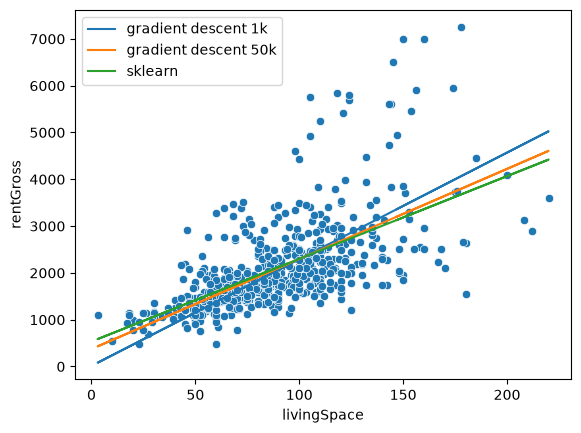

In [15]:
sns.scatterplot(data=train_df, x='livingSpace', y='rentGross')
plt.plot(x_train, predict(x_train, w_1k, b_1k), label='gradient descent 1k')
plt.plot(x_train, predict(x_train, w_50k, b_50k), label='gradient descent 50k')
plt.plot(x_train, predict(x_train, w_sklearn, b_sklearn), label='sklearn')
plt.legend()

plt.show()

The three lines are nearly indistinguishable in the 50–150 $m^2$ range, where most of the training data actually lives.
They only diverge visibly near the edges, where there are very few points to constrain the fit.

More importantly, regardless of which method is used, a straight line does not fit this data particularly well. The spread around all three lines is wide and uneven. `livingSpace` alone clearly is not enough, we need more features in order to predict `rentGross`.

### 7.3 Performance on the test set

We use the test dataset to compute the same error measure on data the model never saw during training. 
This checks whether the fit holds up on new listings, rather than only looking good on the data it was trained on.

With a single feature and enough training examples, we don't expect a large gap between train and test results, but the check is done directly rather 
than assumed.

In [16]:
# Load the test dataset
test_df = pd.read_csv('../data/test.csv')

In [17]:
# Produce np.array with only the 'livingSpace' and 'rentGross' values
x_test = test_df['livingSpace'].values
y_test = test_df['rentGross'].values

In [18]:
# Calculate J for each model
gd_1k_cost = compute_cost(x_test, y_test, w_1k, b_1k)
gd_50k_cost = compute_cost(x_test, y_test, w_50k, b_50k)
gd_sklearn_cost = compute_cost(x_test, y_test, w_sklearn, b_sklearn)

In [19]:
# Calculate RMSE
rmse_1k_train = np.sqrt(2 * history_1k[-1])
rmse_50k_train = np.sqrt(2 * history_50k[-1])
rmse_sklearn_train = np.sqrt(2 * sklearn_cost)

rmse_1k_test = np.sqrt(2 * gd_1k_cost)
rmse_50k_test = np.sqrt(2 * gd_50k_cost)
rmse_sklearn_test = np.sqrt(2 * gd_sklearn_cost)

In [20]:
final_comparison = pd.DataFrame({
    'Model': ['1k iterations', '50k iterations', 'sklearn'],
    'rmse_train': [rmse_1k_train, rmse_50k_train, rmse_sklearn_train],
    'rmse_test': [rmse_1k_test, rmse_50k_test, rmse_sklearn_test]
})
final_comparison

,Model,rmse_train,rmse_test
0,1k iterations,771.679727,653.030964
1,50k iterations,752.385180,616.679684
2,sklearn,750.331751,609.310055


Somewhat counterintuitively, RMSE on the test set is lower than on the training set for all three methods (by 140–150 CHF, recall RMSE is in 
the same unit as `rentGross`). 
With a test set this small (~160 listings), some variation from a single random split is expected, it likely landed on a slightly "easier" subset of listings. 
What matters here is that train and test errors are in the same ballpark and move together across all three methods — 
there's no sign of the model failing to generalize.

## 8. Final considerations

`livingSpace` alone captures a real but partial signal: strong enough to correlate clearly with `rentGross` (0.62) and produce a line with a visible 
trend, but not near enough to predict rent accurately. 
The scatter plots make this obvious: a wide, uneven spread around the fitted line, especially for larger apartments.

The hand-written gradient descent works correctly, it converges toward the same solution as scikit-learn but on unscaled `livingSpace` values convergence is slow and takes tens of thousands of iterations to catch up.
This isn't a flaw in the implementation, it's a direct consequence of not having scaled the feature.

Gradient descent isn't the right tool for a model this small, scikit-learn solves plain linear regression exactly, with a closed-form formula, in a 
fraction of the time. 
Implementing it by hand here is about learning the 
mechanism itself: it's the same mechanism used later for models where no 
closed-form solution exists at all, like neural networks with many parameters.

Gradient descent isn't the right tool for a model this small, scikit-learn solves plain linear regression exactly, with a closed-form formula, in a 
fraction of the time.
Gradient descent is about learning the mechanism itself, so it gives its best for models where no closed-form solution exists at all. 